
# TRNG Project



## background
We read some articles and start with several main ideas, here a brief explanation-
1. The first one is to use the diffrent oscilator jitters for entropy source. we took one fast oscilator (32Mhz) for a COUNTER peripheral that inside the XMEGA mcu and we talk anouther independent oscillator that runs for RTC (real time counter). We use the jitter and the noise f this oscillators as an entropy source, After each OVF of the RTC we took the COUNTER value (the 8 lsb bits).

2. we took the ADC peripheral of the mcu and want to use some analog entropy (sensors) and digitized them to get random bits. we try two sources that we have inside the MCU - VCC/10, TEMP SENSOR. we see that in room conditions the temp gives us ~ 5 bits if entopy for sample, and vcc/10 ~ 3 bits per sample, we take it as an start point and trying to achive the best results. 

## 1) Build firmware

In [177]:
import chipwhisperer as cw
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import trange

scope = cw.scope()
target = cw.target(scope, cw.targets.SimpleSerial2)
scope.default_setup()

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 13795595                  to 37294190                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 0                         to 29538459                 
scope.clock.adc_rate                     changed from 0.0                       to 29538459.0               
scope.clock.clkgen_

In [144]:
%%bash
pwd

/mnt/c/Users/alona/ChipWhisperer/chipwhisperer/secure-hardware/TRNG/combined_trng/jupyter


In [149]:
%%bash
make -C ../src/ PLATFORM=CWLITEXMEGA SS_VER=SS_VER_2_1


make: Entering directory '/mnt/c/Users/alona/ChipWhisperer/chipwhisperer/secure-hardware/TRNG/combined_trng/src'
No CRYPTO_TARGET passed - defaulting to TINYAES128C
Building for platform CWLITEXMEGA with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_2_1
SS_VER set to SS_VER_2_1
Blank crypto options, building for AES128
.
Welcome to another exciting ChipWhisperer target build!!
avr-gcc (GCC) 7.3.0
Copyright (C) 2017 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CWLITEXMEGA 
.
Compiling:
-en     adc_utils.c ...
-e Done!
.
Compiling:
-en     main.c ...
-e Done!
.
Compiling:
-en     reset.c ...
-e Done!
.
Compiling:
-en     rng.c ...
-e Done!
.
Compiling:
-en     timers.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/simpleserial/simpleserial.c ...
-e Done!
.
Compiling:
-en     ../../../../firmware/mcu/hal/hal.c ...
-e Done!


## 2) Program target (XMEGA on CW303)

In [153]:
hex = "../src/build/combined_trng-CWLITEXMEGA.hex"
cw.program_target(scope, cw.programmers.XMEGAProgrammer, hex)

XMEGA Programming flash...
XMEGA Reading flash...
Verified flash OK, 4505 bytes


## 3) Acquire random bits - Approach A: RTC vs TCC jitter

## senity check

why the first always falls???????

In [173]:
# Ask target for that chunk
scmd = 1
want = 10
target.send_cmd('b',scmd,want.to_bytes(1,'little'))

# Read exactly 'want' bytes (no ack check until final)
chunk = target.simpleserial_read('r', want, timeout=200000)
if chunk is None or len(chunk) != want:
    print("Bad block, skipping…")

print("Received", len(chunk), "bytes:", chunk.hex())

Received 10 bytes: 3990d4f69e73ad4a595f


# maybe to move becasue he will see how we take it

In [ ]:
import numpy as np
import logging

# Silence ChipWhisperer "Target" warnings
logging.getLogger("ChipWhisperer Target").setLevel(logging.ERROR)

# Parameters
NUM_TESTS = 1000   # how many restart runs
BYTES_PER_SAMPLE = 125   # 1000 bits minimum
CHUNK = 100          # safe per-request size
scmd = 1


all_samples = []

for i in range(NUM_TESTS):
    print(f"[{i+1}/{NUM_TESTS}] collecting...")

    buf = bytearray()
    remaining = BYTES_PER_SAMPLE

    while remaining > 0:
        target.flush()   # reset UART buffers
        want = min(CHUNK, remaining)
        # Ask target for that chunk
        target.send_cmd('b',scmd,want.to_bytes(1,'little'))

        chunk = target.simpleserial_read('r', want, timeout=2000)
        if chunk is None or len(chunk) != want:
            print("Bad block, skipping this sample...")
            continue

        buf.extend(chunk)
        remaining -= want

    # Store if successful
    if buf is not None:
        all_samples.append(np.frombuffer(buf, dtype=np.uint8))


# Save all samples into one .npy file
all_samples = np.array(all_samples, dtype=np.uint8)
# np.save("../data/restart_test_samples_temp_and_vcc_samples_3bit_concat.npy", all_samples)

# print(f"Saved {len(all_samples)} samples to restart_test_samples.npy")


[1/1000] collecting...
[2/1000] collecting...
[3/1000] collecting...
[4/1000] collecting...
[5/1000] collecting...
[6/1000] collecting...
[7/1000] collecting...
[8/1000] collecting...
[9/1000] collecting...
[10/1000] collecting...
[11/1000] collecting...
[12/1000] collecting...
[13/1000] collecting...
[14/1000] collecting...
[15/1000] collecting...
[16/1000] collecting...
[17/1000] collecting...
[18/1000] collecting...
[19/1000] collecting...
[20/1000] collecting...
[21/1000] collecting...
[22/1000] collecting...
[23/1000] collecting...
[24/1000] collecting...
[25/1000] collecting...
[26/1000] collecting...
[27/1000] collecting...
[28/1000] collecting...
[29/1000] collecting...
[30/1000] collecting...
[31/1000] collecting...
[32/1000] collecting...
[33/1000] collecting...
[34/1000] collecting...
[35/1000] collecting...
[36/1000] collecting...
[37/1000] collecting...
[38/1000] collecting...
[39/1000] collecting...
[40/1000] collecting...
[41/1000] collecting...
[42/1000] collecting...
[

bit 0: p1=0.50240
bit 1: p1=0.50130
bit 2: p1=0.50378
bit 3: p1=0.50285
bit 4: p1=0.50227
bit 5: p1=0.50398
bit 6: p1=0.49992
bit 7: p1=0.50582


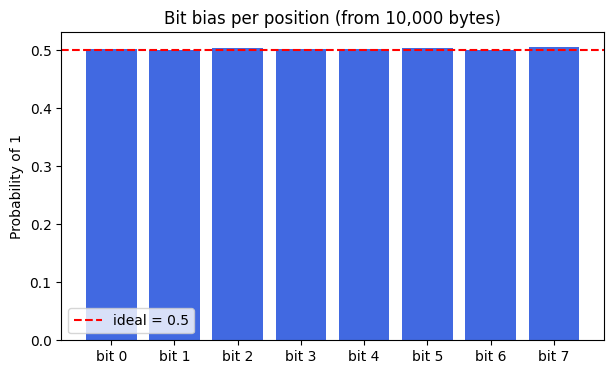


Byte distribution stats:
Min prob: 0.0034, Max prob: 0.0044, Expected = 0.0039


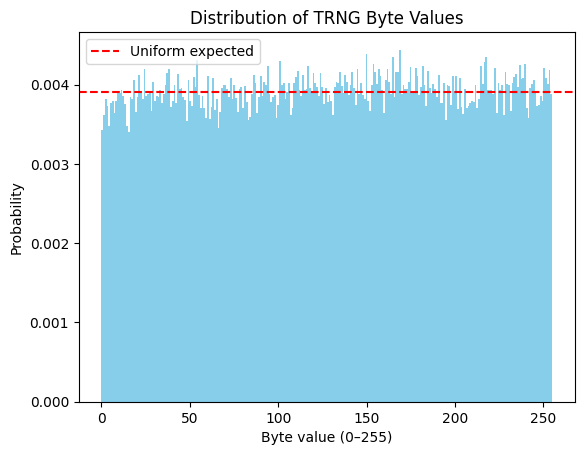

In [178]:
import numpy as np
import time
import logging   # <-- add this

# Silence ChipWhisperer "Target" warnings
logging.getLogger("ChipWhisperer Target").setLevel(logging.ERROR)

CHUNK = 100            # safe per-request size
I = 1250
N = I*CHUNK               # total bytes you want
buf = bytearray()
scmd = 1
# Loop until we have N bytes
remaining = N
while remaining > 0:
    target.flush()
    want = min(CHUNK, remaining)


    # Ask target for that chunk
    target.send_cmd('b',scmd,want.to_bytes(1,'little'))

    # Read exactly 'want' bytes (no ack check until final)
    chunk = target.simpleserial_read('r', want, timeout=200000)
    if chunk is None or len(chunk) != want:
        print("Bad block, skipping…")
        continue
    # if chunk is None:
    #     raise RuntimeError("Timeout waiting for target")

    buf.extend(chunk)
    remaining -= want
    # time.sleep(1)   # 10 ms gap between chunks


# ---------- Analysis ----------
data = np.frombuffer(buf, dtype=np.uint8)
biases = []

for b in range(8):
    ones = np.count_nonzero((data >> b) & 1)
    p1 = ones / len(data)
    biases.append(p1)
    print(f"bit {b}: p1={p1:.5f}")

# ---------- Plot ----------
plt.figure(figsize=(7,4))
plt.bar(range(8), biases, color="royalblue")
plt.axhline(0.5, color="red", linestyle="--", label="ideal = 0.5")
plt.xticks(range(8), [f"bit {i}" for i in range(8)])
plt.ylabel("Probability of 1")
plt.title("Bit bias per position (from 10,000 bytes)")
plt.legend()
plt.show()


# ===== 3. Byte value distribution =====
values, counts = np.unique(data, return_counts=True)
probs = counts / len(data)

print("\nByte distribution stats:")
print(f"Min prob: {probs.min():.4f}, Max prob: {probs.max():.4f}, Expected = {1/256:.4f}")

plt.hist(data, bins=256, range=(0, 255), density=True, color='skyblue')
plt.axhline(1/256, color='r', linestyle='--', label="Uniform expected")
plt.xlabel("Byte value (0–255)")
plt.ylabel("Probability")
plt.title("Distribution of TRNG Byte Values")
plt.legend()
plt.show()

# np.save("../data/1m_bit_random_data_temp_and_vcc_samples_3bit_concat.npy", data)

In [92]:
# Load data
restart_data = np.load("../data/restart_test_samples_temp_and_vcc_samples_3bit_concat.npy")
sequential_data = np.load("../data/1m_bit_random_data_temp_and_vcc_samples_3bit_concat.npy")

bit 0: p1=0.49744
bit 1: p1=0.49924
bit 2: p1=0.50107
bit 3: p1=0.50385
bit 4: p1=0.49997
bit 5: p1=0.50003
bit 6: p1=0.49871
bit 7: p1=0.49882


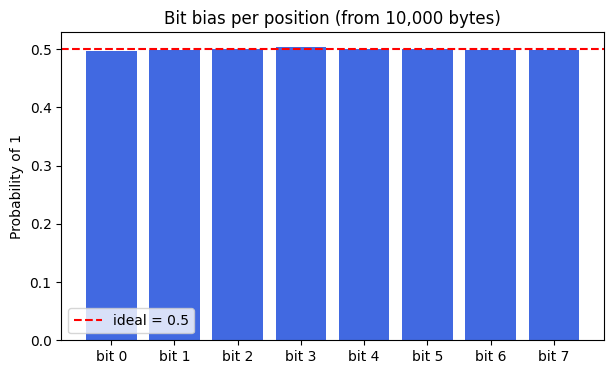


Byte distribution stats:
Min prob: 0.0034, Max prob: 0.0044, Expected = 0.0039


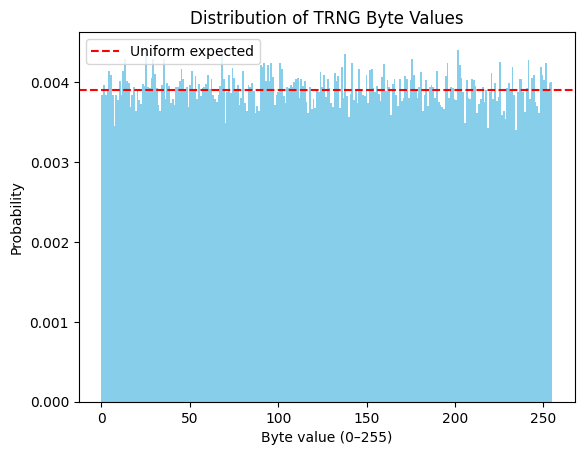

In [121]:
import numpy as np
import time,zlib
import logging   # <-- add this

# Silence ChipWhisperer "Target" warnings
logging.getLogger("ChipWhisperer Target").setLevel(logging.ERROR)


buf = bytearray()
scmd = 1

for i in range(25000):
    target.flush()
    want = 20


    # Ask target for that chunk
    target.send_cmd('b',scmd,want.to_bytes(1,'little'))

    # Read exactly 'want' bytes (no ack check until final)
    chunk = target.simpleserial_read('r', want, timeout=200000)
    if chunk is None or len(chunk) != want:
        print("Bad block, skipping…")
        continue
    # if chunk is None:
    #     raise RuntimeError("Timeout waiting for target")
    calc_crc = zlib.crc32(chunk) & 0xFFFFFFFF
    crc_bytes = calc_crc.to_bytes(4, "little")  # N-bit → 4 bytes

    buf.extend(crc_bytes)
    # time.sleep(1)   # 10 ms gap between chunks


# ---------- Analysis ----------
data = np.frombuffer(buf, dtype=np.uint8)
biases = []

for b in range(8):
    ones = np.count_nonzero((data >> b) & 1)
    p1 = ones / len(data)
    biases.append(p1)
    print(f"bit {b}: p1={p1:.5f}")

# ---------- Plot ----------
plt.figure(figsize=(7,4))
plt.bar(range(8), biases, color="royalblue")
plt.axhline(0.5, color="red", linestyle="--", label="ideal = 0.5")
plt.xticks(range(8), [f"bit {i}" for i in range(8)])
plt.ylabel("Probability of 1")
plt.title("Bit bias per position (from 10,000 bytes)")
plt.legend()
plt.show()


# ===== 3. Byte value distribution =====
values, counts = np.unique(data, return_counts=True)
probs = counts / len(data)

print("\nByte distribution stats:")
print(f"Min prob: {probs.min():.4f}, Max prob: {probs.max():.4f}, Expected = {1/256:.4f}")

plt.hist(data, bins=256, range=(0, 255), density=True, color='skyblue')
plt.axhline(1/256, color='r', linestyle='--', label="Uniform expected")
plt.xlabel("Byte value (0–255)")
plt.ylabel("Probability")
plt.title("Distribution of TRNG Byte Values")
plt.legend()
plt.show()

np.save("../data/1m_bit_random_data_temp_and_vcc_samples_3bit_concat_crc.npy", data)

In [122]:
sequential_data = np.load("../data/1m_bit_random_data_temp_and_vcc_samples_3bit_concat_crc.npy")
# --- Sequential test: write one long file ---
bits_seq = np.unpackbits(sequential_data)
# Pack bits into bytes
packed = np.packbits(bits_seq)
packed.tofile("C:\\Users\\alona\\ChipWhisperer\\chipwhisperer\\secure-hardware\\TRNG\\sts-2.1.2\\data\\sequential\\sequential_stream_crc_800k.bin")
print(packed[0:8])


[ 20  49  95 224  30  48 230 207]


In [ ]:
import numpy as np

# Load data
restart_data = np.load("../data/restart_test_samples_temp_and_vcc_samples_3bit_concat.npy")
sequential_data = np.load("../data/1m_bit_random_data_temp_and_vcc_samples_3bit_concat.npy")
all_bits = []

# --- Restart test: write 1000 files (one per restart sample) ---
for i, sample in enumerate(restart_data):
    # Convert bytes to bits
    bits = np.unpackbits(sample)
    all_bits.append(bits)
    # Save as binary file

# Convert list of arrays into one long NumPy array
all_bits = np.concatenate(all_bits)
packed_res = np.packbits(bits_seq)

packed_res.tofile(f"C:\\Users\\alona\\ChipWhisperer\\chipwhisperer\\secure-hardware\\TRNG\\sts-2.1.2\\data\\restart\\restart_sample.bin")

# --- Sequential test: write one long file ---
bits_seq = np.unpackbits(sequential_data)
# Pack bits into bytes
packed = np.packbits(bits_seq)
packed.tofile("C:\\Users\\alona\\ChipWhisperer\\chipwhisperer\\secure-hardware\\TRNG\\sts-2.1.2\\data\\sequential\\sequential_stream_regular2.bin")
print(packed[0:8])


[ 95 180  48 161 148   7   2 197]


In [112]:
import numpy as np


base_file = "C:\\Users\\alona\\ChipWhisperer\\chipwhisperer\\secure-hardware\\TRNG\\sts-2.1.2\\data\\sequential\\"
# Load the full packed bitstream
data = np.fromfile(base_file + "sequential_stream.bin", dtype=np.uint8)

# Decide number of sequences (e.g. 10)
n_parts = 10
part_size = len(data) // n_parts

for i in range(n_parts):
    chunk = data[i*part_size : (i+1)*part_size]
    chunk.tofile(base_file+f"seq_part{i+1}.bin")


In [180]:
from scipy.stats import entropy,beta

H = entropy(probs, base=2)
print(f"Shannon entropy: {H:.4f} bits per byte (ideal = 8)")

p_max = probs.max()
Hmin_byte = -np.log2(p_max)
print(f"Min-entropy (per byte): {Hmin_byte:.4f} bits; p_max={p_max:.6f}")


# Optional: 99% lower bound using counts
N = counts.sum()            # total samples
c_max = counts.max()        # count of most common byte
alpha = 0.01                # 99% confidence
pmax_upper = beta.ppf(1 - alpha, c_max + 1, N - c_max)  # upper bound on p_max
Hmin_lb_byte = -np.log2(pmax_upper)
print(f"99% lower bound H_min (per byte): {Hmin_lb_byte:.4f} bits")

Shannon entropy: 7.9983 bits per byte (ideal = 8)
Min-entropy (per byte): 7.8204 bits; p_max=0.004424
99% lower bound H_min (per byte): 7.6787 bits


In [181]:
from scipy.stats import chisquare

# Build observed histogram (256 bins, one per possible byte value)
observed, _ = np.histogram(data, bins=256, range=(0, 256))

# Expected: uniform distribution with same total count
expected = np.full(256, len(data) / 256)

# Chi-square test
chi2, pval = chisquare(observed, expected)
print(f"Chi-square = {chi2:.2f}, p = {pval:.3e}")



Chi-square = 298.58, p = 3.154e-02


Autocorrelation lag 1: -0.004866
Autocorrelation lag 2: -0.001629
Autocorrelation lag 3: 0.000664
Autocorrelation lag 4: -0.000879
Autocorrelation lag 5: -0.000054
Autocorrelation lag 6: 0.001851
Autocorrelation lag 7: 0.000318
Autocorrelation lag 8: -0.000113
Autocorrelation lag 12: 0.000649
Autocorrelation lag 16: -0.000329
Autocorrelation lag 32: -0.000143
Autocorrelation lag 64: -0.000267


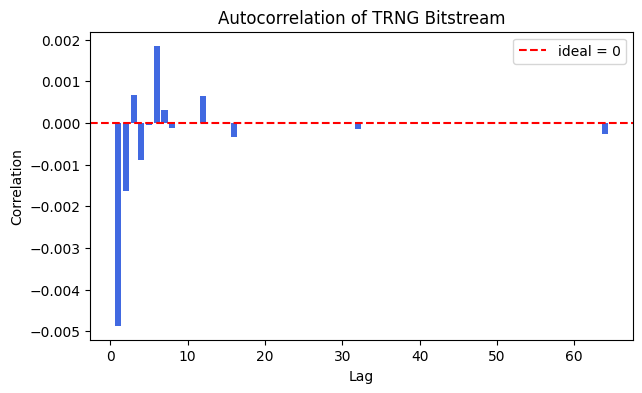

In [183]:
import numpy as np
import matplotlib.pyplot as plt

# Convert bytes → bits (flatten into 0/1 array)
bits = np.unpackbits(data).astype(float)

def autocorr(bits, lag):
    """Compute autocorrelation at a given lag safely."""
    if lag >= len(bits):
        return np.nan
    return np.corrcoef(bits[:-lag], bits[lag:])[0, 1]

# Choose lags to test
lags = [1, 2, 3,4,5,6,7, 8, 12, 16, 32, 64]
results = {}

for lag in lags:
    ac = autocorr(bits, lag)
    results[lag] = ac
    print(f"Autocorrelation lag {lag}: {ac:.6f}")

# --- Plot autocorrelation results ---
plt.figure(figsize=(7,4))
plt.bar(results.keys(), results.values(), color="royalblue")
plt.axhline(0, color="red", linestyle="--", label="ideal = 0")
plt.ylabel("Correlation")
plt.xlabel("Lag")
plt.title("Autocorrelation of TRNG Bitstream")
plt.legend()
plt.show()


In [139]:
import numpy as np
from scipy.stats import chisquare

def poker_test(bits, m_values=[2,3,4,5,6,8]):
    N = len(bits)
    results = []
    for m in m_values:
        num_chunks = N // m
        if num_chunks < 50:
            continue  # not enough samples for this m

        # group into m-bit chunks
        chunks = np.packbits(bits[:num_chunks*m].reshape(-1, m), axis=-1, bitorder='little').flatten()
        freqs = np.bincount(chunks, minlength=2**m)

        # expected counts (uniform)
        expected = np.full(2**m, num_chunks / (2**m))
        chi2, pval = chisquare(freqs, expected)

        results.append((m, chi2, pval))

    return results



bits = np.unpackbits(data)  # turn your bytes into bitstream
results = poker_test(bits)

for m, chi2, pval in results:
    print(f"m={m}: Chi²={chi2:.2f}, p={pval:.3f}")



m=2: Chi²=7.27, p=0.064
m=3: Chi²=2.55, p=0.923
m=4: Chi²=35.74, p=0.002
m=5: Chi²=33.83, p=0.333
m=6: Chi²=82.24, p=0.052
m=8: Chi²=286.85, p=0.083


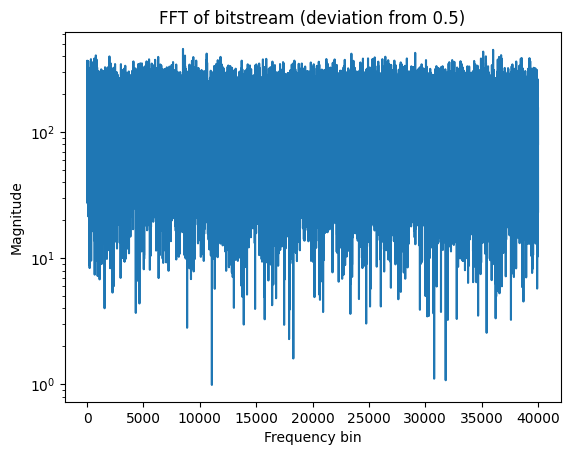

In [140]:
import matplotlib.pyplot as plt

fft_vals = np.fft.fft(bits - 0.5)
plt.semilogy(np.abs(fft_vals[:len(fft_vals)//2]))
plt.title("FFT of bitstream (deviation from 0.5)")
plt.xlabel("Frequency bin")
plt.ylabel("Magnitude")
plt.show()


In [ ]:
import sts-2.1.2 as sts


## 6) Cleanup / disconnect (optional)

In [245]:

try:
    target.dis()
except Exception:
    pass
try:
    scope.dis()
except Exception:
    pass
print("Disconnected.")


Disconnected.
